# Dia 17/09 — M3: Keypoints com MediaPipe

**Capacitação PneumoVision** · IFPE · INPaR · Financiamento FACEPE

Vamos gerar os **keypoints** do seu vídeo com o `extract.py` do projeto e depois **entender e
visualizar** o resultado (o JSON). Cada parâmetro está comentado.

## 1. Gerar os keypoints (no terminal / Colab)

Rode o extrator do projeto sobre o seu vídeo do M2. No Colab, use `!` na frente:

In [21]:
!pip install -r requirements.txt

In [22]:
import sys
!{sys.executable} -m pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# (execute no terminal, ou no Colab com o ! na frente)
import sys
!{sys.executable} extract.py --input video_m2.mp4 --output keypoints.json


✓ Extração concluída: 558 quadros
  Arquivo: keypoints.json
  Detecção de mãos:  96.6% dos quadros
  Detecção de pose:  100.0% dos quadros


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1789781986.727351   18092 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789781986.741211   10928 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789781986.913638   18064 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1789781986.932853   16944 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.

Extraindo keypoints:   0%|          | 0/558 [00:00<?, ?quadro/s]W0000 00:00:1789781987.078619   10700 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square R

## 2. Preparação e um JSON de exemplo

Para este notebook rodar mesmo sem executar o MediaPipe agora, criamos um JSON de keypoints
**no mesmo formato do projeto**. Depois, é só carregar o seu `keypoints.json` real.

In [24]:
import cv2, numpy as np, math          # cv2/np: desenho e cálculo; math: distância
import matplotlib.pyplot as plt
import json, random, math   # json: ler/escrever; random: simular; math: geometria
random.seed(0)                       # semente fixa -> resultado reproduzível

def gerar_keypoints(n_frames=60, fps=20, taxa_maos=0.92, taxa_pose=0.96):
    frames = []                      # lista de quadros
    com_maos = com_pose = 0          # contadores de deteccao
    for i in range(n_frames):        # para cada quadro do "video"
        hands = []                   # maos detectadas neste quadro
        if random.random() < taxa_maos:      # simula deteccao de mao
            com_maos += 1
            cx = 0.5 + 0.1 * math.sin(i / 5) # centro da mao oscila (simula movimento)
            lm = []                          # 21 landmarks da mao
            for k in range(21):              # MediaPipe: 21 pontos por mao
                dy = -0.15 if k == 8 else 0.0  # landmark 8 = ponta do indicador (mais acima)
                lm.append({"landmark": k,
                           "x": round(cx + 0.02 * math.cos(k), 4),  # x normalizado (0..1)
                           "y": round(0.5 + 0.02 * math.sin(k) + dy, 4),  # y normalizado
                           "z": 0.0,          # profundidade relativa (nao usada aqui)
                           "score": 0.99})    # confianca
            hands.append({"hand": "Right", "landmarks": lm})
        pose = []                    # 33 landmarks do corpo
        if random.random() < taxa_pose:
            com_pose += 1
            for k in range(33):      # MediaPipe: 33 pontos de pose
                pose.append({"landmark": k, "x": 0.5, "y": 0.5, "z": 0.0, "score": 0.9})
        frames.append({"frame": i, "timestamp_ms": int(i * 1000 / fps),
                       "hands": hands, "pose": pose})
    meta = {"video_id": "exemplo", "source_file": "exemplo.mp4", "fps": fps,
            "frames_declared": n_frames, "frames_processed": n_frames,
            "hand_detection_rate": round(com_maos / n_frames, 4),
            "pose_detection_rate": round(com_pose / n_frames, 4)}
    return {"metadata": meta, "frames": frames}

dados = gerar_keypoints(n_frames=60)     # cria dados de exemplo (60 quadros)
import json
with open("keypoints_exemplo.json", "w", encoding="utf-8") as f:
    json.dump(dados, f)                   # salva no formato do projeto
print("JSON de exemplo criado")

JSON de exemplo criado


## 3. Carregar e entender a estrutura

In [25]:
import json
with open("keypoints.json", encoding="utf-8") as f:  # troque pelo seu keypoints.json
    kp = json.load(f)                     # carrega o JSON como dicionário

print("Chaves do topo:", list(kp.keys()))            # 'metadata' e 'frames'
print("Metadata:", kp["metadata"])                    # info do vídeo e da extração
print("Nº de quadros:", len(kp["frames"]))            # tamanho da lista de quadros
print("Exemplo de quadro (chaves):", list(kp["frames"][0].keys()))  # frame, hands, pose

Chaves do topo: ['metadata', 'frames']
Metadata: {'video_id': 'ec0fa385-5ef4-4d8a-888d-e655259b6ca9', 'source_file': 'video_m2.mp4', 'fps': 30.0, 'frames_declared': 558, 'frames_processed': 558, 'hand_detection_rate': 0.9659, 'pose_detection_rate': 1.0, 'config': {'max_hands': 2, 'detect_pose': True, 'min_detection_confidence': 0.5, 'min_tracking_confidence': 0.5}}
Nº de quadros: 558
Exemplo de quadro (chaves): ['frame', 'timestamp_ms', 'hands', 'pose']


## 4. Uma mão: 21 landmarks

Cada mão tem 21 pontos. Alguns úteis: 0 = punho, 4 = ponta do polegar, 8 = ponta do indicador.

In [26]:
# Procura o primeiro quadro que tenha mão detectada
quadro_com_mao = next(f for f in kp["frames"] if f["hands"])  # 1º com lista de mãos não vazia
mao = quadro_com_mao["hands"][0]           # a primeira mão do quadro
lms = mao["landmarks"]                      # os 21 landmarks
print("mão:", mao["hand"], "| nº de landmarks:", len(lms))
print("punho (0):", lms[0])                 # coordenadas normalizadas (0..1)
print("ponta do indicador (8):", lms[8])

mão: Right | nº de landmarks: 21
punho (0): {'landmark': 0, 'x': 0.303496, 'y': 1.001683, 'z': 0.0, 'score': 0.7545}
ponta do indicador (8): {'landmark': 8, 'x': 0.377912, 'y': 0.891943, 'z': -0.068158, 'score': 0.7545}


## 5. Desenhar os keypoints em um quadro

As coordenadas são **normalizadas** (0 a 1). Para desenhar, multiplicamos por largura/altura.

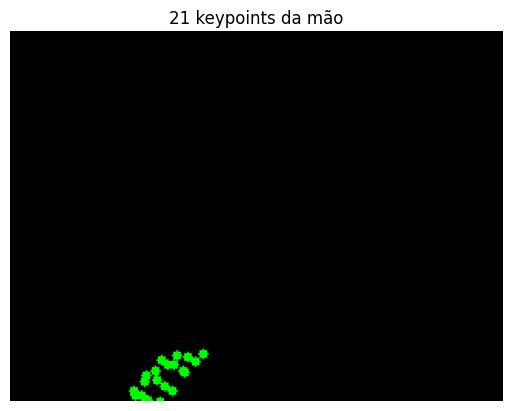

In [27]:
W, H = 320, 240                             # tamanho do "canvas" para desenhar
canvas = np.zeros((H, W, 3), dtype=np.uint8)  # imagem preta

for p in lms:                               # para cada landmark da mão
    x = int(p["x"] * W)                     # x normalizado -> pixel (coluna)
    y = int(p["y"] * H)                     # y normalizado -> pixel (linha)
    cv2.circle(
        canvas,                             # imagem onde desenhar
        (x, y),                             # centro do ponto (x, y)
        3,                                  # raio do ponto (pixels)
        (0, 255, 0),                        # cor BGR: verde
        -1,                                 # -1: preenchido
    )
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))  # BGR->RGB p/ exibir
plt.title("21 keypoints da mão"); plt.axis("off"); plt.show()

## 6. Primeira feature: distância indicador–punho

Uma *feature* resume o gesto. Aqui, a distância entre a ponta do indicador (8) e o punho (0)
em cada quadro — o tipo de sinal que, nas Semanas 1–2, vira regra/classificador.

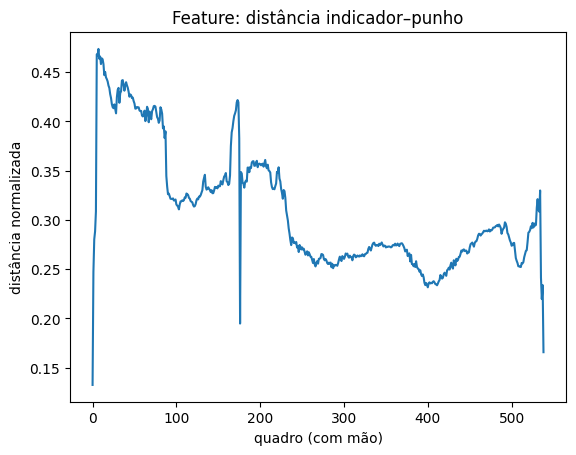

distância média: 0.3104


In [28]:
def dist(a, b):                             # distância euclidiana entre 2 landmarks
    return math.hypot(a["x"] - b["x"], a["y"] - b["y"])  # hypot = sqrt(dx^2 + dy^2)

serie = []                                  # distância por quadro (quando há mão)
for f in kp["frames"]:                       # percorre todos os quadros
    if f["hands"]:                           # só quando há mão detectada
        l = f["hands"][0]["landmarks"]       # landmarks da 1ª mão
        serie.append(dist(l[8], l[0]))       # distância indicador(8) - punho(0)
plt.plot(serie)                              # evolução da feature no tempo
plt.xlabel("quadro (com mão)"); plt.ylabel("distância normalizada")
plt.title("Feature: distância indicador–punho"); plt.show()
print("distância média:", round(sum(serie) / len(serie), 4))

## 7. Taxa de detecção

In [29]:
com_mao = sum(1 for f in kp["frames"] if f["hands"])  # quadros com mão
total = len(kp["frames"])                              # total de quadros
print(f"quadros com mão: {com_mao}/{total} = {100*com_mao/total:.1f}%")
print("hand_detection_rate (metadata):", kp["metadata"]["hand_detection_rate"])

quadros com mão: 539/558 = 96.6%
hand_detection_rate (metadata): 0.9659


## 8. (Opcional) Rodar o MediaPipe direto no notebook

Só no Colab/terminal com internet (baixa o modelo `hand_landmarker.task` — ver README).
Este trecho não roda aqui; está aqui para você conhecer a API.

In [ ]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

base = mp_python.BaseOptions(
    model_asset_path="hand_landmarker.task",   # arquivo do modelo (baixe conforme o README)
)
opts = mp_vision.HandLandmarkerOptions(
    base_options=base,                         # modelo a usar
    running_mode=mp_vision.RunningMode.IMAGE,  # IMAGE: processa uma imagem por vez
    num_hands=2,                               # nº máximo de mãos a detectar
    min_hand_detection_confidence=0.5,         # confiança mínima para aceitar a detecção
)
detector = mp_vision.HandLandmarker.create_from_options(opts)   # cria o detector

bgr = cv2.imread("mao.jpg")                    # carrega uma foto de mão (BGR)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)     # MediaPipe espera RGB
mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)  # embrulha para o MediaPipe
res = detector.detect(mp_img)                  # detecta (modo IMAGE)
print("mãos detectadas:", len(res.hand_landmarks))

## 9. Sua entrega (M3)

Rode o `extract.py` sobre o **seu** vídeo do M2 e entregue o `keypoints.json` gerado + **3
frases** sobre o que há dentro dele (o que é `metadata` e o que são os `frames`).

**Critério de aceite:** JSON gerado com sucesso; você identifica onde estão a taxa de
detecção e os landmarks. Referência de dúvidas: Prof. Diogo (MediaPipe/keypoints).